# Exploratory Data Analysis

En este notebook analizaremos los datos que vamos a utilizar.

Los datos que vamos a utilizar son 2 datasets, uno con noticias reales y otro con noticias falsas, los cuales provienen de Kaggle: https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset


In [1]:
# contractions library para cambiar palabras como "can't" pot "cannot"
!pip install contractions

#Cargar datos y librerias
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import contractions
import re
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords


fake = pd.read_csv("/content/Fake.csv")
true = pd.read_csv("/content/True.csv")

fake["label"] = 0
true["label"] = 1

df = pd.concat([fake, true], ignore_index=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 4.4 MB/s eta 0:00:00


In [2]:
#Mostramos un ejemplo de noticia verdadera y otro de noticia falsa
print("Noticias reales")
print(true.head(5))
print("\n\n")
print("--------------------------------------")
print("Noticias falsas")
print(fake.head(5))

Noticias reales
                                               title  \
0  As U.S. budget fight looms, Republicans flip t...   
1  U.S. military to accept transgender recruits o...   
2  Senior U.S. Republican senator: 'Let Mr. Muell...   
3  FBI Russia probe helped by Australian diplomat...   
4  Trump wants Postal Service to charge 'much mor...   

                                                text       subject  \
0  WASHINGTON (Reuters) - The head of a conservat...  politicsNews   
1  WASHINGTON (Reuters) - Transgender people will...  politicsNews   
2  WASHINGTON (Reuters) - The special counsel inv...  politicsNews   
3  WASHINGTON (Reuters) - Trump campaign adviser ...  politicsNews   
4  SEATTLE/WASHINGTON (Reuters) - President Donal...  politicsNews   

                 date  label  
0  December 31, 2017       1  
1  December 29, 2017       1  
2  December 31, 2017       1  
3  December 30, 2017       1  
4  December 29, 2017       1  



-------------------------------------

Nuestro dataset tiene la siguiente información:

* title: Titulo de la noticia
* text: Texto extraido de la noticia
* subject: categoría de la noticia
* date: fecha de publicación
* label: 1 si es real, 0 si es falsa

# Comprobaciones y limpieza previa de los datos

Se van a realizar las siguientes operaciones de limpieza del dataset:



1.   Comprobar duplicados
2.   Comprobar tipos de datos y missing values
3.   Analizar si existe inbalanceo de clases



In [3]:
# Filas duplicadas
df.duplicated().sum()

np.int64(209)

Hay 209 filas repetidas, que vamos a borrar

In [4]:
df.drop_duplicates(inplace=True)
df.shape

(44689, 5)

Nos quedamos con 44.689 noticias en total para utilizar

In [5]:
#Tipo de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 44689 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44689 non-null  object
 1   text     44689 non-null  object
 2   subject  44689 non-null  object
 3   date     44689 non-null  object
 4   label    44689 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 2.0+ MB


Todas las columnas tienen 44.689 datos, lo cual indica que no hay missing values.

Por otro lado, actualmente la columna "date" es de tipo object (String), lo cual vamos a cambiar para que sea un datetime. Hay 2 tipos de fechas guardadas:


* Dia-Mes_abreviado-numero_año : **12-Feb-18**
* Dia Mes_largo, año_completo: **12 December, 2019**

Hay que limpiarlo para tener el mismo formato y pasarlo a datetime para las representaciones siguientes



In [6]:
# Diccionario de mapeo meses (inglés y español) a números
meses_map = {
    'Jan': 1, 'January': 1, 'Enero': 1,
    'Feb': 2, 'February': 2, 'Febrero': 2,
    'Mar': 3, 'March': 3, 'Marzo': 3,
    'Apr': 4, 'April': 4, 'Abril': 4,
    'May': 5, 'Mayo': 5,
    'Jun': 6, 'June': 6, 'Junio': 6,
    'Jul': 7, 'July': 7, 'Julio': 7,
    'Aug': 8, 'August': 8, 'Agosto': 8,
    'Sep': 9, 'September': 9, 'Septiembre': 9,
    'Oct': 10, 'October': 10, 'Octubre': 10,
    'Nov': 11, 'November': 11, 'Noviembre': 11,
    'Dec': 12, 'December': 12, 'Diciembre': 12
}


# Inicializar columnas vacías
df['dia'] = ''
df['mes'] = ''
df['año'] = ''


# Proceso de limpieza para aquellas con "-"
mask_guion = df['date'].str.contains('-')  # formato 19-Feb-18

df[mask_guion]["date"].str.contains('-')

df_temp=df.loc[mask_guion, 'date'].str.split('-', expand=True)[[0,1,2]]
ds_dia=df_temp[0]
ds_mes=df_temp[1]
ds_mes=ds_mes.map(meses_map)
ds_año=df_temp[2]

df.loc[mask_guion, ['dia']]=ds_dia
df.loc[mask_guion, ['mes']]=ds_mes
df.loc[mask_guion, ['año']]="20"+ds_año



#Ahora para el otro formato
# Crear un booleano para su formato
mask_coma = df['date'].str.contains(',')   # formato December 31, 2017


mes_dia = df.loc[mask_coma, 'date'].str.split(', ', expand=True)  # ['December 31', '2017']
df.loc[mask_coma, 'año'] = mes_dia[1].str.strip()
mes_dia_split = mes_dia[0].str.split(' ', expand=True)  # ['December', '31']
df.loc[mask_coma, 'mes'] = mes_dia_split[0].map(meses_map)
df.loc[mask_coma, 'dia'] = mes_dia_split[1]

# Con todo limpio, las uno en formato datetime YYYY-MM-DD'
df['date_dt'] = df['año'] + '-' + df['mes'].astype(str).str.zfill(2) + '-' + df['dia'].astype(str).str.zfill(2)
df['date_dt'] = pd.to_datetime(df['date_dt'], format='%Y-%m-%d',errors='coerce')
#Drop las columnas intermedias de dia,mes, año
df=df.drop(columns=["date","dia","mes","año"])

#Quiero que la columna se llame date
df["date"]=df["date_dt"]
df=df.drop(columns=["date_dt"])
#Dropeo los nans. He analizado previamente y estos son noticias que en vez de texto son urls, se eliminan
df=df.dropna(subset=["date"])

In [7]:
#Me aseguro de que no queden noticias mal enviadas, que son solo urls
df["title"].str.contains('https://').value_counts()

#En el core del texto si que se pueden tener https:// que lleven a imagenes u otras noticias, eso sera limpiado en los siguientes pasos

,count
title,
False,44644


label
0    0.524886
1    0.475114
Name: proportion, dtype: float64


<Axes: xlabel='label', ylabel='count'>

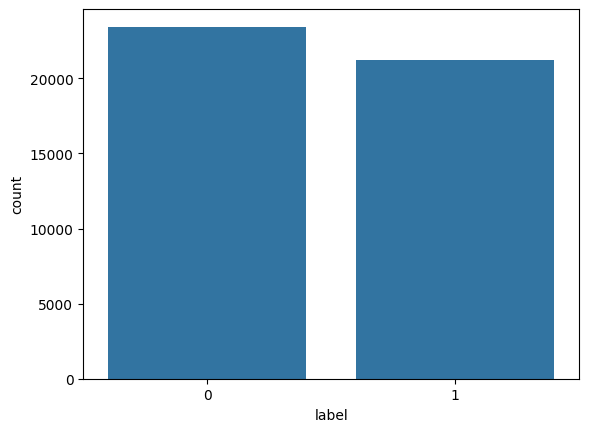

In [8]:
#Balanceo de clases

print(df["label"].value_counts(normalize=True))
sns.countplot(x="label", data=df)

Los datasets estan bastante balanceados. El dataset contiene un 52.5% de noticias falsas y un 47.5% noticias verdaderas.


  Es muy importante analizar el balanceo de las clases ya que si estas están desbalanceadas, el modelo puede terminar prediciendo siempre un tipo de clase. Es decir, si el 95% de los datos fueran de noticias reales y solo un 5% de falsas, si el modelo acierta un 95% de las veces lo está haciendo igual de mal que predecir que siempre es una noticia real.  

 Para no tener problemas con el desbalance, se puede usar upsampling para agregar más ejemplos de la clase minoritaria, o downsampling para quitar ejemplos de la clase mayoritaria.

 En nuestro caso, como la diferencia es de tan solo un 5%, hemos decidido no realizar ninguna medida extra ya que este desbalance no es lo suficientemente grande como para afectar el entrenamiento y rendimiento de los modelos.

# Procesado del texto y Feature Engineering para el modelo ML de clasificación

En esta fase hemos tenido en cuenta los siguientes factores:
1. Incluir los meses en los textos no tenia valor ya que tenemos una columna de fecha de publicacion. Como hay noticias que vienen con tweets, estos incluyen el usuario, dia y mes en que se publico, por lo que para no cambiar la estadística real de las veces dicha la palabra mes por culpa de los tweets se han decidido eliminar por completo añadiendolo como stopword.
2. Se han mantenido los usuarios de tweeter (delimitados por @nombre) para estudiar si hay correlacion entre post de tweeter y noticias falsas.
3. Se ha incluido especial atención a las abreviaturas como "U.S." ya que inicialmente se estaban cambiando por "yous" debido a que se pasaban a minuscula, se eliminaban los puntos, y la palabra mas cercana a "us" es "yous". Se ha cambiado para tenerlo como "unitedstates" para saber que se hace referencia al pais.

In [9]:
# Data science libraries
import csv
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# NLP libraries
import nltk
from nltk.corpus import stopwords
from textblob import Word
from wordcloud import WordCloud
from nltk.stem import WordNetLemmatizer
import plotly.express as px


# Download stopwords and wordnet
nltk.download("stopwords")
nltk.download("wordnet")

# Load stopwords
#No incluyo los meses porque en los tweets salen todo el tiempo e inflan el numero de palabras, y no aportan info real
months = ["january", "february", "march", "april", "may", "june",
          "july", "august", "september", "october", "november", "december"]

stop_words = set(stopwords.words('english')).union(months)
# Create lemmatizer
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [10]:
#Ahora vamos a hacer el preprocesado

def preprocess_text_column(df_data, column, stop_words=stop_words, lemmatizer=lemmatizer):
    """
    Preprocess a pandas DataFrame column efficiently.
    Steps:
    1. Lowercase
    2. Expand contractions
    3. Remove non-alphanumeric characters and digits
    4. Remove stop words
    5. Lemmatize
    """

    # Define abbreviation replacements
    ABBREVIATIONS = {
      r"U\.S\.": "united-states" ,
      r"U\.S": "united-states"
    }


    df=df_data.copy()

    # Replace known abbreviations
    for pattern, replacement in ABBREVIATIONS.items():
        df[column] = df[column].str.replace(pattern, replacement, regex=True, flags=re.IGNORECASE)


    # Lowercase
    df[column] = df[column].str.lower()

    # Expand contractions - pasar de "can't" a "cannot"
    df[column] = df[column].apply(contractions.fix)


    # Remove possessive 's - para que si la palabra es "obama's" pase a ser "obama" y no "obamas"
    df[column] = df[column].str.replace(r"'s\b", '', regex=True)


    # Remove non-alphanumeric characters and digits (except @ para los tweets)
    df[column] = df[column].str.replace(r'[^a-z\s@]', '', regex=True) #nos quedamos con los @

    # Remove stopwords and lemmatize
    stop_words_set = set(stop_words)  # Fast lookup
    df[column] = df[column].apply(
        lambda text: ' '.join(
            lemmatizer.lemmatize(word) for word in text.split() if word not in stop_words_set
        )
    )

    return df



In [11]:
df_processed=preprocess_text_column(df,"title")
df_processed=preprocess_text_column(df_processed,"text")

print("Comprobamos su funcionamiento")

print("Sin procesar:\n", df["title"][0])
print("Procesado: \n",df_processed["title"][0])

Comprobamos su funcionamiento
Sin procesar:
  Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing
Procesado: 
 donald trump sends embarrassing new year eve message disturbing


# Analizamos frecuencia de las palabras

1. Analizamos la frecuencia total de las palabras de todo el dataset
2. Analizamos la frecuencia de las palabras segun sea un texto real o falso

/tmp/ipykernel_747/1222424158.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


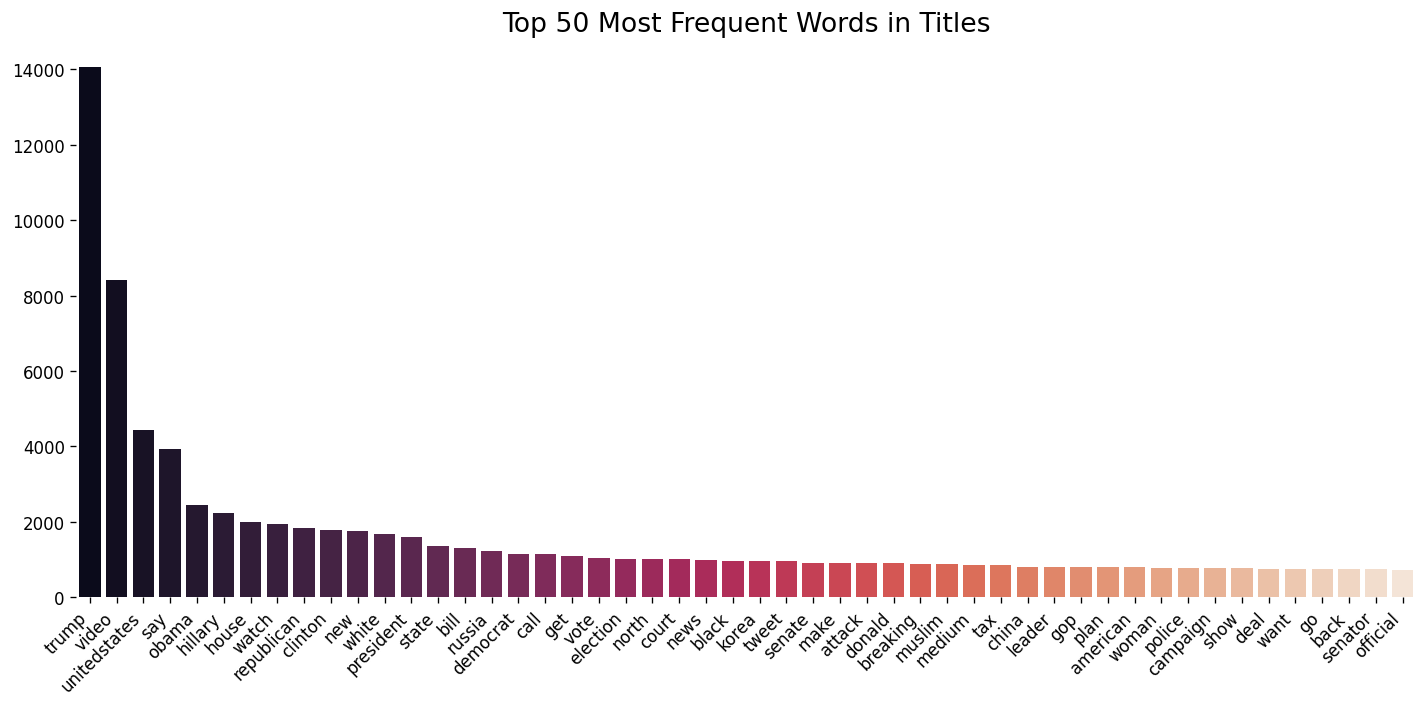

In [12]:
# Compute word frequencies for TITLE
word_count_title = (
    pd.Series(" ".join(df_processed["title"]).split())
      .value_counts()
      .reset_index()
      .rename(columns={"index": "word", "count": "frequency"})
)

# Parameters
top_n = 50
palette = "rocket"  # New palette: gradient from dark to light red/orange

# Plot
plt.figure(figsize=(12, 6), dpi=120)
sns.barplot(
    data=word_count_title.head(top_n),
    x="word",
    y="frequency",
    palette=palette
)
plt.title(f'Top {top_n} Most Frequent Words in Titles', fontsize=16)
plt.xlabel("")
plt.ylabel("")
plt.xticks(rotation=45, ha="right")
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

/tmp/ipykernel_747/1619219730.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


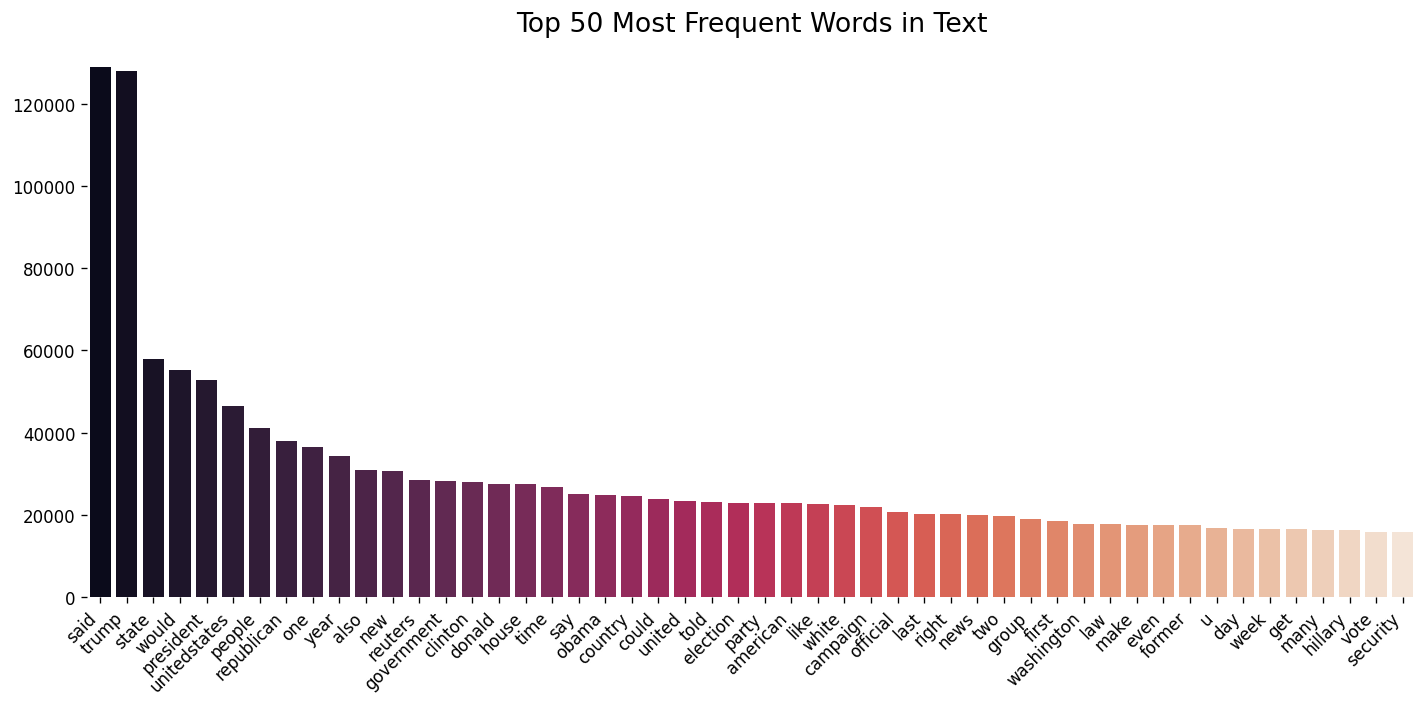

In [13]:
# Compute word frequencies for TEXT
word_count_text = (
    pd.Series(" ".join(df_processed["text"]).split())
      .value_counts()
      .reset_index()
      .rename(columns={"index": "word", "count": "frequency"})
)

# Parameters
top_n = 50
palette = "rocket"  # New palette: gradient from dark to light red/orange

# Plot
plt.figure(figsize=(12, 6), dpi=120)
sns.barplot(
    data=word_count_text.head(top_n),
    x="word",
    y="frequency",
    palette=palette
)
plt.title(f'Top {top_n} Most Frequent Words in Text', fontsize=16)
plt.xlabel("")
plt.ylabel("")
plt.xticks(rotation=45, ha="right")
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

Notas tomadas:

1. La palabra "reuters" parece un error pero es correcta, hace referencia a un medio de comunicación que se llama así.
2. La palabra "gop" hace referencia a la pagina web de los republicanos, es correcta.
3. La palabra "u" hace referencia tanto a "you" como a "us", se refiere a la 2nd persona.

**Ahora comparamos para ver si hay diferencias de frecuencia entre textos reales y falsos**

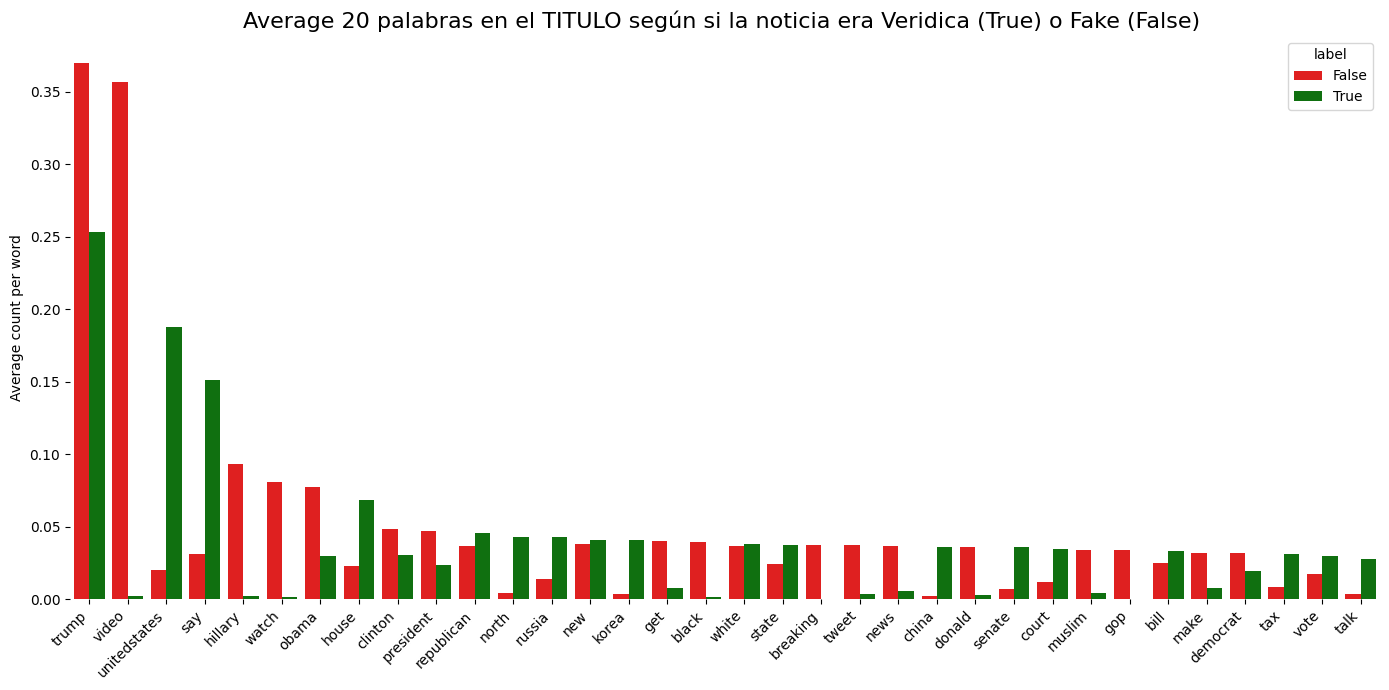

In [14]:

top_n = 20  # top words overall

# Step 1: Compute frequencies per label
freq_dict = {}
for label, group in df_processed.groupby("label"):
    word_counts = pd.Series(" ".join(group["title"]).split()).value_counts()
    freq_dict[label] = word_counts/len(group)

# Step 2: Get union of top N words across all labels
all_top_words = set()
for counts in freq_dict.values():
    all_top_words.update(counts.head(top_n).index)

# Step 3: Build dataframe with frequencies per label, fill missing words with 0
freq_df = []
for label, counts in freq_dict.items():
    for word in all_top_words:
        freq_df.append({
            "word": word,
            "label": label,
            "frequency": counts.get(word, 0)
        })

freq_df = pd.DataFrame(freq_df)
freq_df=freq_df.sort_values("frequency", ascending=False)

label_map = {0: "False", 1: "True"}
freq_df["label"] = freq_df["label"].map(label_map)
custom_palette = {"False": "red", "True": "green"}

# Step 4: Plot side-by-side comparison
plt.figure(figsize=(14, 7))
sns.barplot(
    data=freq_df,
    x="word",
    y="frequency",
    hue="label",
    palette=custom_palette
)
plt.title(f'Average {top_n} palabras en el TITULO según si la noticia era Veridica (True) o Fake (False) ', fontsize=16)
plt.xlabel("")
plt.ylabel("Average count per word")
plt.xticks(rotation=45, ha="right")
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

**Nota**: Puesto que no tenemos el mismo número de textos reales y falsos, para los siguientes gráficos donde comparemos el número de palabras vistas entre reales y falsos, se va a realizar la media de palabras por texto, es decir se cuenta el número de apariciones total de la palabra y se divide por el número de textos que tenemos de cada categoría.

En este gráfico podemos ver cómo la mayoría de noticias falsas hacen alusión a TRUMP usando palabras como "Trump" y "Donald" mucho más que en los reales. También mencionan en más ocasiones los nombres de políticos como Obama , Hilary y Clinton.

Especial interés como palabras como "video", "black", "breaking", "tweet" y "news", "muslim", "gop" son muy utilizadas por los textos falsos y casi nada por los reales. Algunas explicaciones posibles son:

* Escribir "breaking news" para que la noticia parezca más verídica y la gente quiera clicar.
* Alusión a que incluye un "video" con lo ocurrido.
* "Black" y "muslim" pueden ser utilizadas para llamar la atención y que la gente quiera clicar en la noticia
* "tweet" y "gop" pueden ser usadas ya que Donald Trump utiliza mucho tweeter en su campaña. GOP hace referencia a la página web republicana.


Esto nos indica que las noticias falsas suelen ser políticas, lo cual se

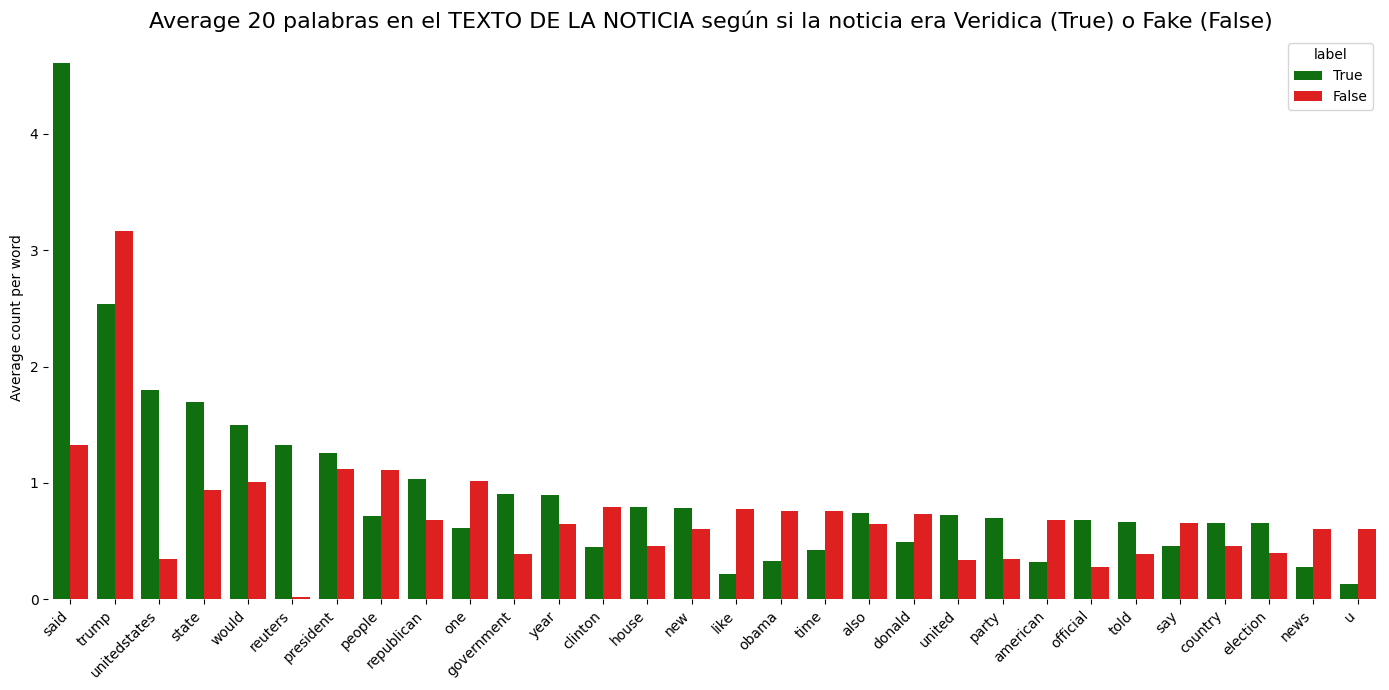

In [36]:
top_n = 20  # top words overall

# Step 1: Compute frequencies per label
freq_dict = {}
for label, group in df_processed.groupby("label"):
    word_counts = pd.Series(" ".join(group["text"]).split()).value_counts()
    freq_dict[label] = word_counts/len(group)

# Step 2: Get union of top N words across all labels
all_top_words = set()
for counts in freq_dict.values():
    all_top_words.update(counts.head(top_n).index)

# Step 3: Build dataframe with frequencies per label, fill missing words with 0
freq_df = []
for label, counts in freq_dict.items():
    for word in all_top_words:
        freq_df.append({
            "word": word,
            "label": label,
            "frequency": counts.get(word, 0)
        })

freq_df = pd.DataFrame(freq_df)
freq_df=freq_df.sort_values("frequency", ascending=False)

label_map = {0: "False", 1: "True"}
freq_df["label"] = freq_df["label"].map(label_map)
custom_palette = {"False": "red", "True": "green"}

# Step 4: Plot side-by-side comparison
plt.figure(figsize=(14, 7))
sns.barplot(
    data=freq_df,
    x="word",
    y="frequency",
    hue="label",
    palette=custom_palette
)
plt.title(f'Average {top_n} palabras en el TEXTO DE LA NOTICIA según si la noticia era Veridica (True) o Fake (False) ', fontsize=16)
plt.xlabel("")
plt.ylabel("Average count per word")
plt.xticks(rotation=45, ha="right")
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

Tal y como muestra la gráfica, existen diferencias entre las palabras más utilizadas por los textos reales y falsos. Poniendo algunos ejemplos:

**Noticias Reales**
* Citan fuentes reales como "Reuters" u "official".
* Al hacer citas dicen la palabra "said" en vez de otras.
* Se refieren mucho más al país (UnitedStates, States) que las falsas

**Noticias Falsas**
* Mencionan mucho más a candidatos políticos como "Donald" "Trump", "Obama", "Clinton"
* Como no pueden decir que sean reales, usan palabras como "news" más a menudo.
* Se refieren al pais de forma informal (US) en vez de como en los reales (U.S.). Lo sabemos ya que en el preprocesado se ha sustituido la abreviatura real (U.S.) por (unitedStates); mientras que (US) se ha dejado sin sustituir y al realizar el procesado la raiz obtenida es ("u"), palabra 20 más utilizada con un pico claro en noticias falsas.

# Numero de palabras

El siguiente analisis busca encontrar correlación entre si los textos reales y los falsos se pueden diferenciar por el número de palabras utilizadas

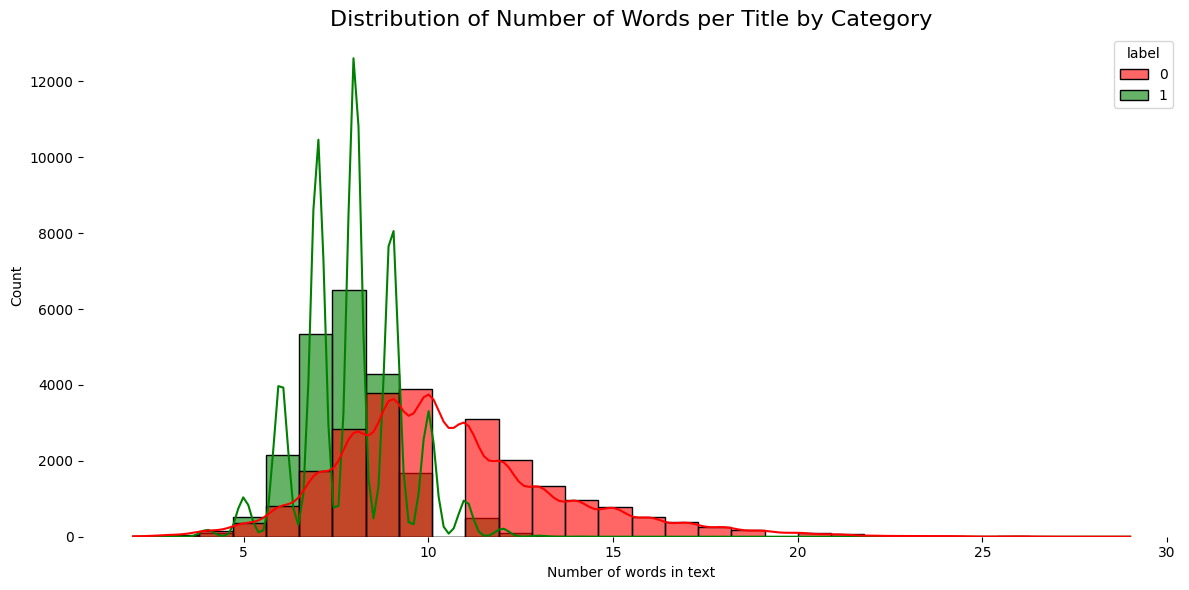

In [16]:
# Step 1: Compute number of words per text
df_processed['word_count'] = df_processed['title'].apply(lambda x: len(x.split()))
custom_palette = {0: "red", 1: "green"}



# Step 3: Plot distribution of words per text by category
plt.figure(figsize=(12, 6))
sns.histplot(
    data=df_processed,
    x='word_count',
    hue='label',
    palette=custom_palette,
    bins=30,
    kde=True,
    alpha=0.6
)
plt.title("Distribution of Number of Words per Title by Category", fontsize=16)
plt.xlabel("Number of words in text")
plt.ylabel("Count")
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

**Conclusion para los títulos**:
Tal y como muestra el historgrama anterior, si un título es muy largo (más de 10 palabras) es muy probable que sea falso

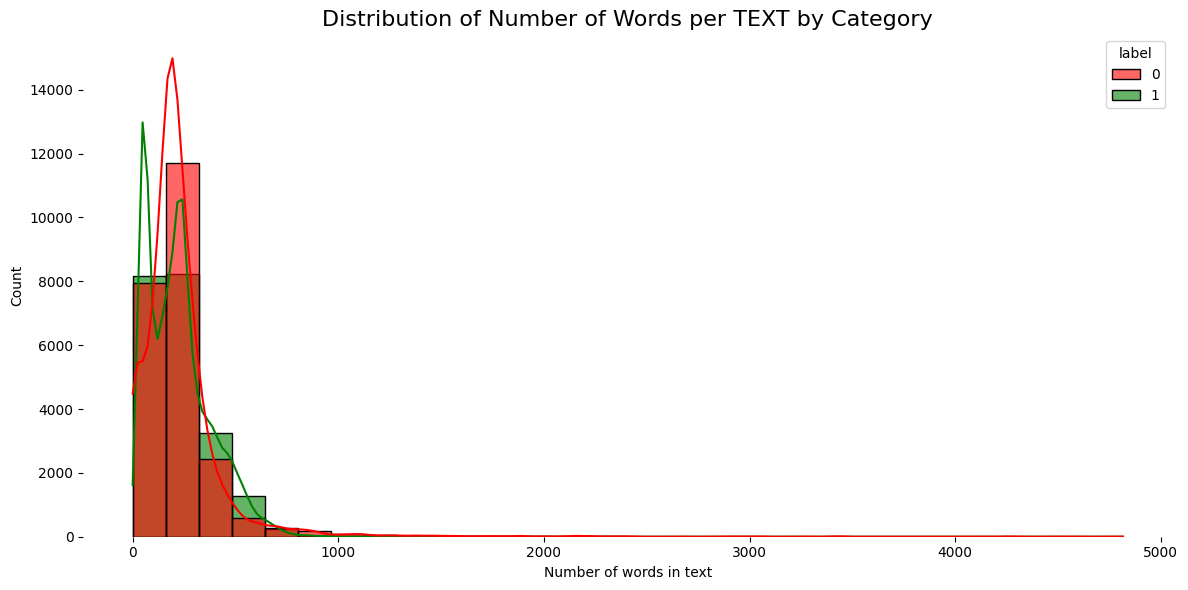

In [17]:
# Step 1: Compute number of words per text
df_processed['word_count'] = df_processed['text'].apply(lambda x: len(x.split()))
custom_palette = {0: "red", 1: "green"}

# Step 2: Plot distribution of words per text by category
plt.figure(figsize=(12, 6))
sns.histplot(
    data=df_processed,
    x='word_count',
    hue='label',
    palette=custom_palette,
    bins=30,
    kde=True,
    alpha=0.6
)
plt.title("Distribution of Number of Words per TEXT by Category", fontsize=16)
plt.xlabel("Number of words in text")
plt.ylabel("Count")
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

In [18]:
#De los textos mas largos, cuantos son reales y cuantos falsos?

df_processed[ df_processed["word_count"]>1000]["label"].value_counts()

,count
label,
0,273
1,19


**Conclusion**: En cuanto al contenido del texto es más dificil analizar si es real o falso solo mirando el número de palabras utilizadas.

Destaca que si el texto es extremadamente largo (+1000 palabras) hay más de un 90% de probabilidades de que sea falso.



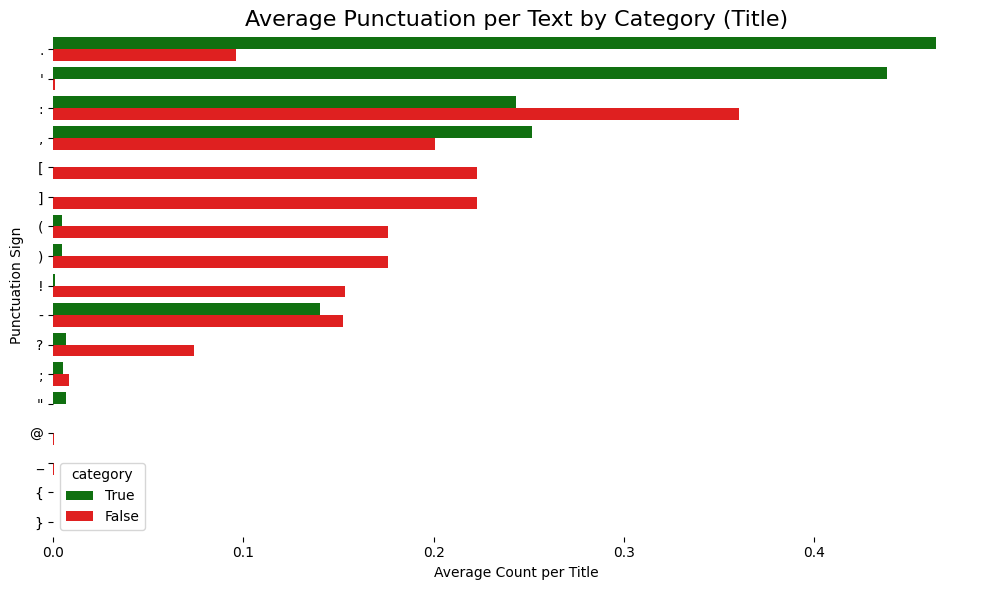

In [19]:
# Define the punctuation characters
punctuation_chars = list("!?.',;:\"-()[]{}@_")

# Function to count a specific punctuation in a string
def count_specific_punct(text, punct):
    return text.count(punct)

# Initialize list to store counts
punct_counts = []

# Loop over categories and punctuation characters
for label, group in df.groupby("label"):
    n_texts = len(group)  # number of texts in this category
    for p in punctuation_chars:
        total_count = group["title"].apply(lambda x: count_specific_punct(x, p)).sum()
        avg_count = total_count / n_texts  # normalize by number of texts
        punct_counts.append({
            "punctuation": p,
            "avg_count": avg_count,
            "category": label
        })

# Convert to DataFrame
punct_df = pd.DataFrame(punct_counts)
punct_df=punct_df.sort_values("avg_count", ascending=False)
label_map = {0: "False", 1: "True"}
punct_df["category"] = punct_df["category"].map(label_map)
custom_palette = {"False": "red", "True": "green"}

plt.figure(figsize=(10,6))
sns.barplot(
    data=punct_df,
    y="punctuation",
    x="avg_count",
    hue="category",
    palette=custom_palette
)
plt.title("Average Punctuation per Text by Category (Title)", fontsize=16)
plt.xlabel("Average Count per Title")
plt.ylabel("Punctuation Sign")
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

Esta represntacion nos muestra la frecuencia de signos de puntuación en los títulos, de la cual se puede extraer la siguiente informacion:

Textos Verdaderos:
1. Los titulos reales suelen contener varias frases o terminar en "." , ya que la frecuencia de "." es mucho mayor que en los Falsos
2. Los titulos reales acostumbran a usar el " ' " con mucha mas frecuencia, lo cual puede ser debido al genitivo sajón el cual se utiliza para denotar posesión en inglés. También podría ser para abreviar verbos (you are = you're)
3. Estos textos están mejor redactados que los falsos, por lo que contienen más "," que los falsos.

Textos falsos:
1. Acostumbran a usar los ":" que los reales. Imagino que para generar clickbait y hacer que el lector piense que alguien famoso ha dicho algo. (Ejemplo: "Famoso ha dicho: no lo quiero...")
2. Muy claramente en cuanto veamos el uso de "!" o"?" podemos estar bastante seguros de que la noticia puede que sea falsa
3. Otros signos de puntuacion en el título como () o [] son usados, muy poco comunes en los verdaderos.
4. Hace menciones a tweeter con los "@"

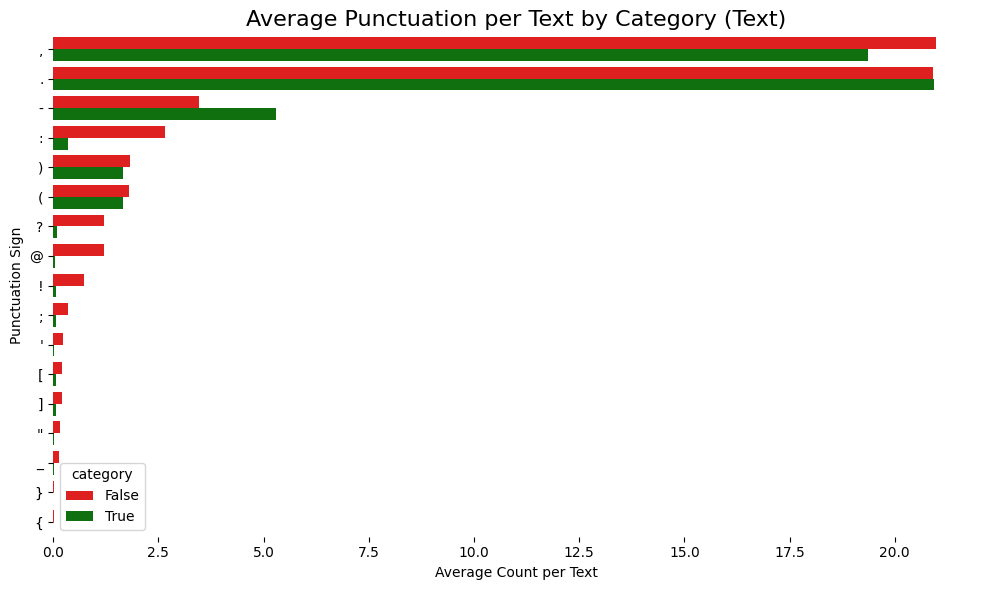

In [20]:
# Define the punctuation characters
punctuation_chars = list("!?.',;:\"-()[]{}@_")

# Function to count a specific punctuation in a string
def count_specific_punct(text, punct):
    return text.count(punct)

# Initialize list to store counts
punct_counts = []

# Loop over categories and punctuation characters
for label, group in df.groupby("label"):
    n_texts = len(group)  # number of texts in this category
    for p in punctuation_chars:
        total_count = group["text"].apply(lambda x: count_specific_punct(x, p)).sum()
        avg_count = total_count / n_texts  # normalize by number of texts
        punct_counts.append({
            "punctuation": p,
            "avg_count": avg_count,
            "category": label
        })

# Convert to DataFrame
punct_df = pd.DataFrame(punct_counts)
punct_df=punct_df.sort_values("avg_count", ascending=False)
label_map = {0: "False", 1: "True"}
punct_df["category"] = punct_df["category"].map(label_map)
custom_palette = {"False": "red", "True": "green"}

plt.figure(figsize=(10,6))
sns.barplot(
    data=punct_df,
    y="punctuation",
    x="avg_count",
    hue="category",
    palette={"False": "red", "True": "green"}
)
plt.title("Average Punctuation per Text by Category (Text)", fontsize=16)
plt.xlabel("Average Count per Text")
plt.ylabel("Punctuation Sign")
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

En el texto de las noticias hay menos diferencias que en los títulos, sin embargo hay características que son útiles para detectar si es real o falso:

1.  Cuando los textos falsos quieren decir que alguien ha dicho algo, usan ":", mientras que los textos reales usan más "-".
2. Los textos falsos usan mucho más las interrogaciones "?" y exclamaciones "!", posiblemente para poner preguntas al lector que les haga pensar de una forma y manipular su pensamiento; y también para llamar su atención y que lea la noticia.
3. Los textos falsos por lo general contienen datos de Twitter, ya que la mayoria contienen los "@" o "_" de los nombres de usuarios mencionados en la noticia. También podría significar que la noticia ha sido creada y divulgada en Twitter.
4. Los textos falsos contienen más abreviaturas, ya que el caracter "`" aparece mucho más que en los reales.
5. Si contiene caracteres raros como "{}", "[]", ";" es probable que sea falsa. Además, el punto y coma es muy poco común en inglés, este caracter  debería alzar las sospechas rápido.

# Analisis por el tema tratado por las noticias.

Vamos a realizar un análisis de los temas tratados por las noticias según el dataset para detectar posibles correlaciones

<Axes: xlabel='count', ylabel='subject'>

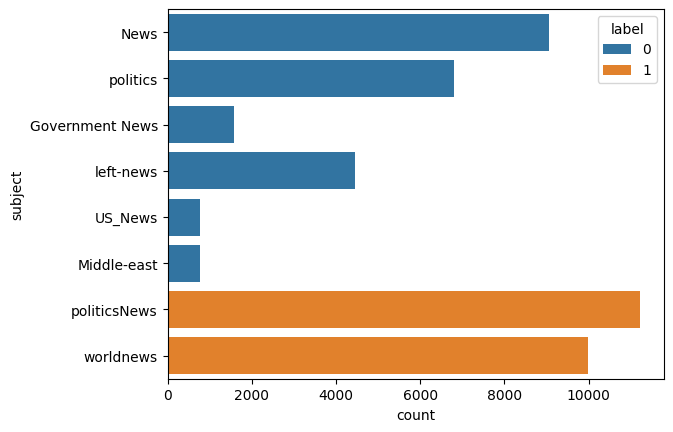

In [21]:
#Analisis por subject

df["subject"].value_counts()
sns.countplot(y="subject", hue="label", data=df)


Estos son los "subjects" donde las noticias vienen etiquetadas. Las categorías no son iguales, por lo que una comparación ahora mismo no sería correcta. Además, hay que compararlos utilizando otra métrica que no sea el conteo, ya que el número de noticias reales y falsas no es igual, una opción sería la probabilidad de que la noticia sea de X categoría con la media.

Procedemos a unir las noticias falsas en 2 categorías, noticias políticas y noticias mundiales.

* **Políticas**: Noticias como "Government News", "left-news", "US_News" y "politics" son claramente políticas
* **Mundiales**: "Middle-east" es claramente una noticia relacionada con el estado del mundo.
* **Necesario exploración**: Las noticias marcadas como "News" no deja claro si son mundiales o del propio pais. Tras análisis de los datos, la categoría a la que se va a añadir "news" es noticias políticas ya que trata de noticias relacionadas con el estado del país, principalmente relacionado con los políticos.



In [23]:
df_processed[df_processed['subject']=="News"]["title"][:10]

,title
0,donald trump sends embarrassing new year eve m...
1,drunk bragging trump staffer started russian c...
2,sheriff david clarke becomes internet joke thr...
3,trump obsessed even obamas name coded website ...
4,pope francis called donald trump christmas speech
5,racist alabama cop brutalize black boy handcuf...
6,fresh golf course trump lash fbi deputy direct...
7,trump said insanely racist stuff inside oval o...
8,former cia director slam trump un bullying ope...
9,watch brandnew protrump ad feature much kissin...


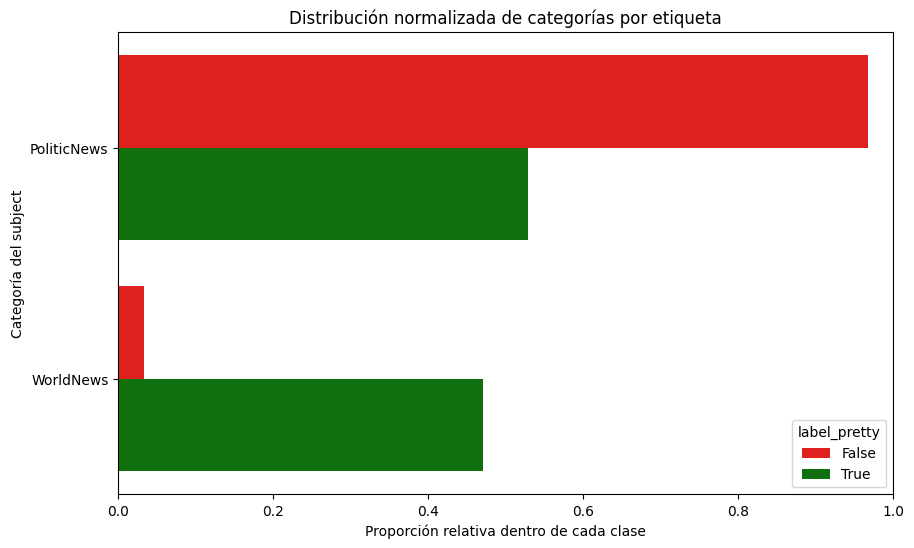

In [35]:
# Crear un diccionario de mapeo
label_map = {0: False, 1: True}

# Aplicar el mapeo a la columna "label"
df_processed["label_pretty"] = df_processed["label"].map(label_map)


# Listas de subjects a agrupar
politic_subjects = ["News","politics","Government News", "left-news", "US_News", "politicsNews"]
world_news = ["Middle-east","worldnews"]

# Crear una nueva columna con el nombre unificado
df_processed['subject_grouped'] = df_processed['subject'].apply(
    lambda x: "PoliticNews" if x in politic_subjects else ("WorldNews" if x in world_news else x)
)



# Contar cuántos datos hay por categoría y etiqueta
counts = df_processed.groupby(["subject_grouped", "label_pretty"]).size().reset_index(name="count")

# Normalizar por clase (label_pretty)
counts["count_norm"] = counts.groupby("label_pretty")["count"].transform(lambda x: x / x.sum())

# Graficar
plt.figure(figsize=(10,6))
sns.barplot(
    data=counts,
    y="subject_grouped",
    x="count_norm",
    hue="label_pretty",
    palette={False:"red", True:"green"}
)
plt.xlabel("Proporción relativa dentro de cada clase")
plt.ylabel("Categoría del subject")
plt.title("Distribución normalizada de categorías por etiqueta")
plt.xlim(0,1)
plt.show()

Esta gráfica nos muestra como la mayoría de textos Falsos tienen como objetivo manipular la opinión política de la gente. Las noticias falsas que son de temas mundiales también buscan manipular la opinión política de la gente, ya que el tema de "middle-east" en ee.uu. es político y polémico ya que cada candidato tiene unas opiniones diferentes sobre las medidas a tomar alli.

Los textos verdaderos en cambio muestran una distribución mucho más uniforme teniendo casi el mismo número de noticias políticas que mundiales.

Es por ello que, el modelo de ML para clasificar noticias debe prestar especial atención a las noticias políticas para detectar si es real o falsa.

In [37]:
#Guardamos el dataset final para usarlo en los siguientes pasos

df_processed.to_csv("processed_data.csv")